# Tutorial 3, Q1b: GD training of a perceptron layer with autograd

In [1]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pylab as plt

## Set the parameter for the layer and training

In [2]:
no_features = 3
no_labels = 2
no_data = 8

lr = 0.1
no_epochs = 100000

SEED = 10
np.random.seed(SEED)

## Generate training data

In [3]:
# generate training data
X = np.random.rand(no_data, no_features)
Y = np.zeros((no_data, no_labels))
Y[:,0] = (X[:,0] + X[:,1]**2 + X[:, 2]**3 + np.random.rand(no_data))/4
Y[:,1] = (X[:,0] + X[:,1] + X[:, 2] + X[:,0]*X[:,1]*X[:,2] + np.random.rand(no_data))/5

print('X = {}'.format(X))
print('Y = {}'.format(Y))
print('alpha = {}'.format(lr))

X = [[0.77132064 0.02075195 0.63364823]
 [0.74880388 0.49850701 0.22479665]
 [0.19806286 0.76053071 0.16911084]
 [0.08833981 0.68535982 0.95339335]
 [0.00394827 0.51219226 0.81262096]
 [0.61252607 0.72175532 0.29187607]
 [0.91777412 0.71457578 0.54254437]
 [0.14217005 0.37334076 0.67413362]]
Y = [[0.36700015 0.46890243]
 [0.36067172 0.37505132]
 [0.34976828 0.24872748]
 [0.48444787 0.41710316]
 [0.36332573 0.28887784]
 [0.43984029 0.51677508]
 [0.59832905 0.51552032]
 [0.27739117 0.37034263]]
alpha = 0.1


## Define the class for a perceptron layer

In [4]:
class PerceptronLayer(nn.Module):
  def __init__(self, no_inputs, no_outputs):
        super().__init__()
        self.perceptron_layer = nn.Sequential(
            nn.Linear(no_inputs, no_outputs),
            nn.Sigmoid()
        )

  def forward(self, x):
        logits = self.perceptron_layer(x)
        return logits

## Initialize the perceptron layer

In [5]:
model = PerceptronLayer(no_features, no_labels)

print(f"Model structure: {model}\n")
for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param} \n")

Model structure: PerceptronLayer(
  (perceptron_layer): Sequential(
    (0): Linear(in_features=3, out_features=2, bias=True)
    (1): Sigmoid()
  )
)

Layer: perceptron_layer.0.weight | Size: torch.Size([2, 3]) | Values : Parameter containing:
tensor([[ 0.4618,  0.1392, -0.1446],
        [-0.0936, -0.2860, -0.0320]], requires_grad=True) 

Layer: perceptron_layer.0.bias | Size: torch.Size([2]) | Values : Parameter containing:
tensor([-0.1360, -0.4487], requires_grad=True) 



## Train the perceptron layer

In [6]:
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=.001)

cost = []
for epoch in range(no_epochs):
    pred = model(torch.tensor(X, dtype=torch.float))
    loss = loss_fn(pred, torch.tensor(Y, dtype=torch.float))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    cost.append(loss.item())

    if epoch%10000 == 9999:
        print('epoch:{}, loss:{}'.format(epoch+1,cost[epoch]))

epoch:10000, loss:0.009134970605373383
epoch:20000, loss:0.008011890575289726
epoch:30000, loss:0.007637248374521732
epoch:40000, loss:0.007379536982625723
epoch:50000, loss:0.007156055420637131
epoch:60000, loss:0.00695363525301218
epoch:70000, loss:0.0067685735411942005
epoch:80000, loss:0.006598291918635368
epoch:90000, loss:0.006440768484026194
epoch:100000, loss:0.0062943631783127785


## Plot the learning curves

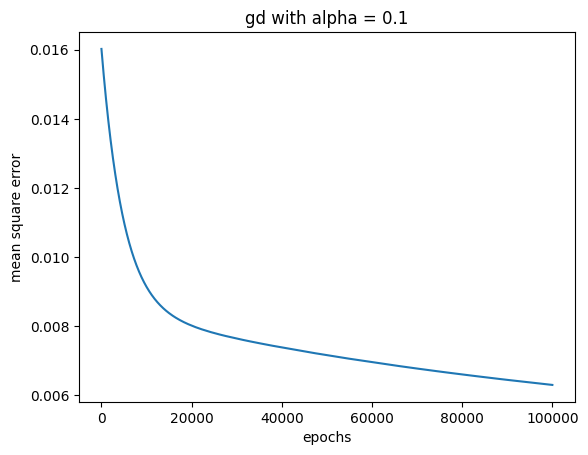

In [7]:
# plot learning curves
plt.figure(1)
plt.plot(range(no_epochs), cost)
plt.xlabel('epochs')
plt.ylabel('mean square error')
plt.title('gd with alpha = {}'.format(lr))
plt.show()

## Plot the training data and the predictions

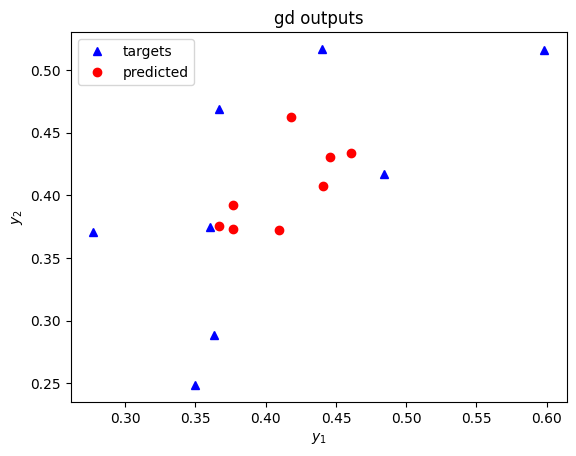

In [8]:
pred = model(torch.tensor(X, dtype=torch.float))
      
plt.figure(2)
plot_targets = plt.plot(Y[:,0], Y[:,1], 'b^', label='targets')
plot_pred = plt.plot(pred[:,0].detach().numpy(), pred[:,1].detach().numpy(), 'ro', label='predicted')
plt.xlabel('$y_1$')
plt.ylabel('$y_2$')
plt.title('gd outputs')
plt.legend()
plt.show()